# Assignment: exact TT ranks, U(1) sectors, and the PROTES generation boundary

Analysis dated October 8, 2026. Notation: assignment size $n$, number of binary variables $N=n^2$.
Variables are in **row-major order**: $x_{11},\ldots,x_{1n},x_{21},\ldots,x_{nn}$, as in `fill_assignment_vectors!`.
Rank results apply to this order. No claim is made that this variable order is optimal.

**Main conclusion:** exact representations of the full indicator in ordinary and symmetric TT require the same total bond dimensions. Each charge sector in the symmetric representation can have degeneracy 1, while the number of sectors remains exponential. A model constructed from 400 samples is a different, generally incomplete indicator. These quantities must not all be called "rank" without qualification.

By default, the notebook reads saved measurements. Long experiments require a separate flag below. Dependencies are listed in `scripts/protes/requirements-scaling.txt`; the experiments use unmodified PROTES, commit `06d447845dd26ffccbc8e95c7545fa1d2617940e`.


In [1]:
from pathlib import Path
import sys, csv, json, math, subprocess
ROOT = Path.cwd()
if not (ROOT / "Project.toml").exists(): ROOT = ROOT.parent
assert (ROOT / "Project.toml").exists(), "Open notebook from the project or examples directory"
sys.path.insert(0, str(ROOT / "scripts/protes"))
import assignment_scaling as analysis
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Markdown
from matplotlib.ticker import PercentFormatter
OUT = ROOT / "data/protes_comparison/scaling"
FIG = ROOT / "examples/pictures"
FIG.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10, "pdf.fonttype": 42})
def savefig(fig, stem):
    fig.savefig(FIG / (stem + ".pdf"), bbox_inches="tight")
    fig.savefig(FIG / (stem + ".png"), dpi=180, bbox_inches="tight")
def table(headers, rows):
    import html
    display(HTML("<table><tr>" + "".join("<th>"+html.escape(str(v))+"</th>" for v in headers) + "</tr>" +
                 "".join("<tr>" + "".join("<td>"+html.escape(str(v))+"</td>" for v in row) + "</tr>" for row in rows) + "</table>"))
print("Python:", sys.executable)
print("Current notebook process affinity:", analysis.baseline.PROCESS.cpu_affinity())


Python: D:\Releases\OhMyU1_public\PROTES\.venv\Scripts\python.exe
Current notebook process affinity: [7]


## 1. The exact indicator and its minimum TT ranks

Consider $F(x)=\mathbf 1\{x\text{ is a permutation matrix}\}$. The minimum exact TT rank at a cut equals the rank of the corresponding matrix unfolding.

At a cut after $k=rn+s$ variables, $r$ complete rows and $s$ positions in the next row have been processed, where $0\le s<n$. Residual constraints are fully determined by the set of used columns and whether a one has been selected in the current row. After permuting the unfolding's rows and columns, each reachable residual state corresponds to a nonempty all-ones block. Different states have disjoint sets of prefixes and suffixes. Each block therefore has rank 1, and the unfolding rank equals the number of such states.

* No one has yet been selected in the partial row: $r$ columns are used. Not all $n-s$ remaining columns may already be used. The number of states is $\binom nr-\binom{s}{r-(n-s)}$.
* A one has already been selected: $r+1$ columns are used, at least one of them among the first $s$. The number of states is $\binom n{r+1}-\binom{n-s}{r+1}$.

Thus,
$$\boxed{R_{rn+s}=\binom nr-\binom{s}{r-n+s}+\binom n{r+1}-\binom{n-s}{r+1}.}$$
Binomial coefficients outside their valid range are zero. Boundary ranks are $R_0=R_{n^2}=1$.
Between rows, $R_{rn}=\binom nr$, but the maximum can occur **within a row**, so the central-binomial estimate alone is insufficient for an exact plot.

$$\binom n{\lfloor n/2\rfloor}\le R_{\max}\le2\binom n{\lfloor n/2\rfloor},\qquad
R_{\max}=\Theta(2^n/\sqrt n)=\Theta(2^{\sqrt N}/N^{1/4}).$$

Growth is exponential in $n$ and subexponential in $N=n^2$. Any finite indicator of $Ax=b$ **can be represented** as a TT; the issue is the required ranks, not representability in principle.


In [2]:
for size in range(2, 6):
    verified = analysis.enumerate_check(size)
    print(f"n={size}: every unfolding verified; max rank={max(verified)}")
table(["n", "N=n²", "rank at middle row boundary", "max exact TT rank"],
      [[n,n*n,math.comb(n,n//2),analysis.max_rank(n)] for n in [4,6,8,10,12,16,20]])

n=2: every unfolding verified; max rank=2
n=3: every unfolding verified; max rank=5
n=4: every unfolding verified; max rank=9
n=5: every unfolding verified; max rank=19


n,N=n²,rank at middle row boundary,max exact TT rank
4,16,6,9
6,36,20,34
8,64,70,125
10,100,252,461
12,144,924,1715
16,256,12870,24309
20,400,184756,352715


## 2. What the U(1) implementation stores

A bond has the form $\bigoplus_q\mathbb R^{d_q}$, with total dimension $D_k=\sum_q d_q$. For the full indicator, each compatible residual charge is one of the states in the preceding proof, and $d_q=1$ suffices. Hence $D_k=R_k$.

In the code, `ChargeIndex.Card` counts sectors, while `LINK_DEGENERACY=1` sets the dimension within each sector. `init_u1_mps` stores only charge-conserving blocks in a dictionary. An ordinary dense TT retains every entry of cores with shape $R_{k-1}\times2\times R_k$. For a binary indicator, each left charge state has at most two outgoing edges, so at $d_q=1$ a symmetric core stores at most $2R_{k-1}$ scalars. The benefit concerns **storage and sparse-block operations**, not disappearance of the full rank. Dictionary and charge-vector metadata are excluded from this scalar estimate.

When constructing a model from $M=400$ samples before EELS, at most $M$ charges have been observed at each cut. Their graph can represent more than 400 complete configurations through path recombination. EELS adds charge states, so the bound $D_k\le400$ no longer necessarily holds afterward. Coverage of all $n!$ solutions is not guaranteed either.

The curves below are measured **in the actual Julia implementation**, using 400 initial random points at each size before training. They do not describe model sizes throughout later optimization iterations. The full-indicator curve uses the proven formula.


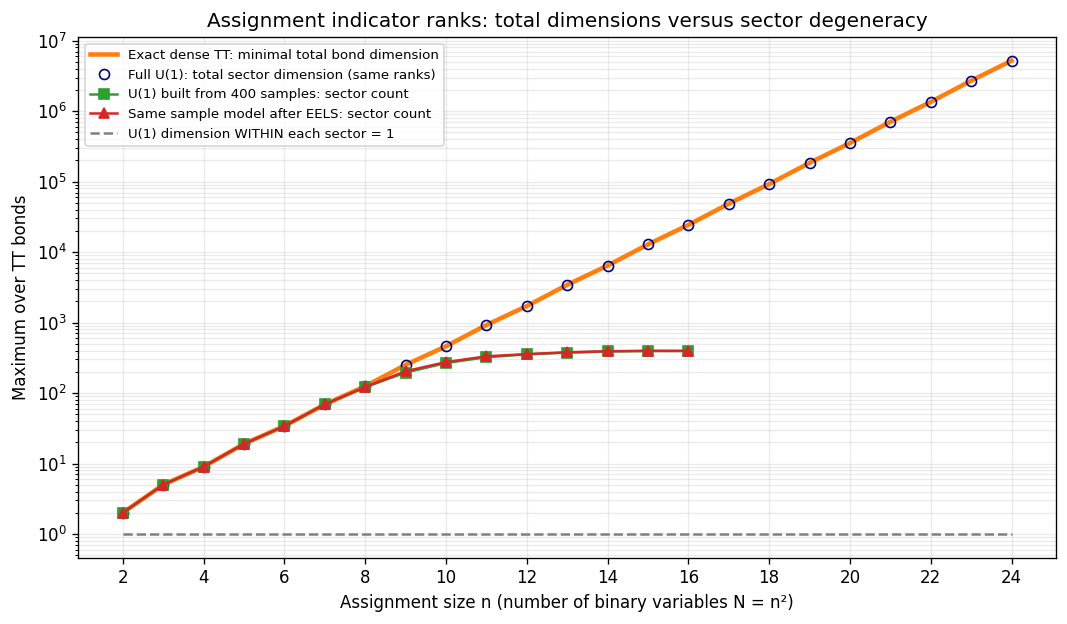

n,N,Exact full rank,400 samples,After EELS
4,16,9,9,9
6,36,34,34,34
8,64,125,121,122
10,100,461,267,275
12,144,1715,355,356
16,256,24309,395,396


In [3]:
RUN_RANK_AUDIT = False
if RUN_RANK_AUDIT:
    subprocess.run(["julia", "--startup-file=no", f"--project={ROOT}", "--threads=1",
                    str(ROOT / "scripts/protes/assignment_rank_audit.jl")], check=True, cwd=ROOT)
rank_file = OUT / "u1_rank_audit.csv"
if not rank_file.exists(): rank_file = ROOT / "examples/protes_scaling_u1_ranks.csv"
with rank_file.open() as f:
    audit = list(csv.DictReader(f))
maxima = {(mode,n): max(int(x["sectors"]) for x in audit if x["mode"]==mode and int(x["n"])==n)
          for mode in ["sample","EELS"] for n in range(2,17)}
for row in audit:
    assert int(row["degeneracy"]) == 1
    assert int(row["sectors"]) <= analysis.exact_rank(int(row["n"]), int(row["cut"]))
ns = np.arange(2,25)
ranks = np.array([analysis.max_rank(int(n)) for n in ns])
fig, ax = plt.subplots(figsize=(9,5.3))
ax.semilogy(ns, ranks, color="tab:orange", lw=2.7, label="Exact dense TT: minimal total bond dimension")
ax.semilogy(ns, ranks, "o", mfc="none", color="navy", ms=6, label="Full U(1): total sector dimension (same ranks)")
small = np.arange(2,17)
ax.semilogy(small, [maxima["sample",int(n)] for n in small], "s-", color="tab:green", label="U(1) built from 400 samples: sector count")
ax.semilogy(small, [maxima["EELS",int(n)] for n in small], "^-", color="tab:red", label="Same sample model after EELS: sector count")
ax.semilogy(ns, np.ones(len(ns)), "--", color="gray", label="U(1) dimension WITHIN each sector = 1")
ax.set(xlabel="Assignment size n (number of binary variables N = n²)", ylabel="Maximum over TT bonds", xticks=np.arange(2,25,2))
ax.grid(alpha=.25, which="both"); ax.legend(fontsize=8, loc="upper left")
ax.set_title("Assignment indicator ranks: total dimensions versus sector degeneracy")
fig.tight_layout(); savefig(fig,"assignment_exact_tt_u1_ranks"); plt.show()
table(["n","N","Exact full rank","400 samples","After EELS"],
      [[n,n*n,analysis.max_rank(n),maxima["sample",n],maxima["EELS",n]] for n in [4,6,8,10,12,16]])

### Why equal full ranks do not imply equal computational costs

The fast `protes()` implementation stores internal cores in a dense array with common rank $R$, containing $2(N-2)R^2+4R$ entries. The estimates below cover **float64 parameters only** at $R=R_{\max}$, excluding gradients, Adam states, and temporary arrays. They describe the particular dense PROTES representation of the full indicator, not a memory lower bound for every TT algorithm.

For the full U(1) indicator with degeneracy 1, the scalar-block count is bounded above by $2\sum_{k=0}^{N-1}R_k$, also stored as float64. Dictionaries and charge vectors add overhead. This table compares **the same complete feasible set**, unlike the curve for a model constructed from 400 points.


In [4]:
memory_rows=[]
for n in [8,10,12,16]:
    rs=[analysis.exact_rank(n,k) for k in range(n*n+1)]
    R=max(rs); dense=8*(2*(n*n-2)*R*R+4*R)
    sparse_upper=8*2*sum(rs[:-1])
    memory_rows.append([n,R,f"{dense/2**30:.3g}",f"{sparse_upper/2**20:.3g}"])
table(["n","Full rank","Dense PROTES parameters, GiB","U(1) scalar blocks upper bound, MiB"],memory_rows)

n,Full rank,"Dense PROTES parameters, GiB","U(1) scalar blocks upper bound, MiB"
8,125,0.0144,0.0508
10,461,0.31,0.266
12,1715,6.22,1.31
16,24309,2.24e+03,29


## 3. Feasible fractions and the limits of a density argument

Under uniform sampling of binary vectors,
$$p_{\rm uniform}=n!/2^{n^2},\qquad \log p_{\rm uniform}=\log\Gamma(n+1)-n^2\log2.$$
However, trained PROTES need not be close to uniform. Even independent bits with $P(x_{ij}=1)=1/n$ yield
$$p_{\rm sparse}=n!n^{-n}(1-1/n)^{n^2-n},$$
which is much larger. A model can also concentrate on a single feasible solution. Thus a small feasible fraction **does not by itself prove** that PROTES will fail.

Distinguish feasible samples, unique feasible points, and **new** feasible points absent from the initial 400 samples. At small $n$, the initial dataset nearly covers the entire space; the expected number of still-unobserved solutions is $n!(1-1/n!)^{400}$.


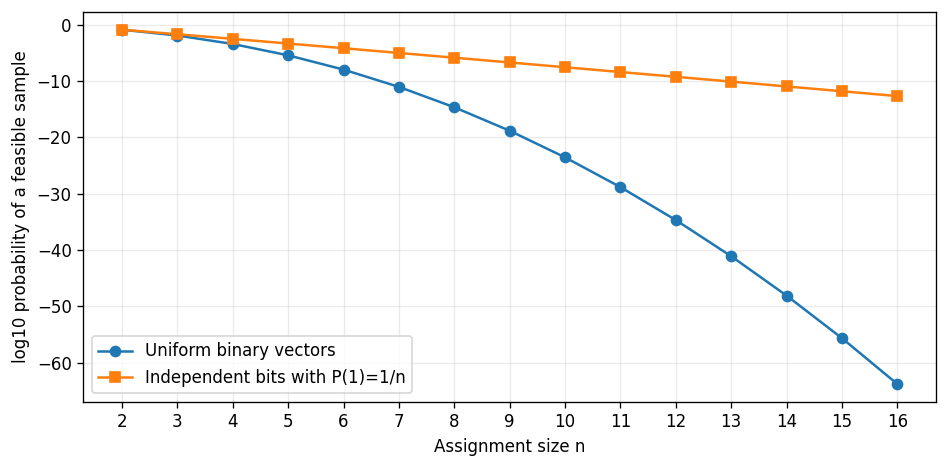

In [5]:
ns = np.arange(2,17)
uniform = [(math.lgamma(int(n)+1)-int(n)**2*math.log(2))/math.log(10) for n in ns]
sparse = [(math.lgamma(int(n)+1)-int(n)*math.log(int(n))+(int(n)**2-int(n))*math.log1p(-1/int(n)))/math.log(10) for n in ns]
fig,ax=plt.subplots(figsize=(8,4))
ax.plot(ns,uniform,"o-",label="Uniform binary vectors")
ax.plot(ns,sparse,"s-",label="Independent bits with P(1)=1/n")
ax.set(xlabel="Assignment size n",ylabel="log10 probability of a feasible sample",xticks=ns)
ax.grid(alpha=.25);ax.legend();fig.tight_layout();savefig(fig,"assignment_feasible_density");plt.show()

## 4. Experiment: searching for new feasible points

The same **data-only** PROTES protocol is used: 400 initial binary configurations; four initial batches of 100; top-10 selection; one Adam step; rank=5; lr=0.05. There is no permutation encoding, masking, or structural TT. Only an external evaluator checks feasibility. A fully infeasible batch does not update the model, as in the previous script. This can leave the model unchanged after unsuccessful initial training.

Small sizes use **separate diagnostic instances**, which do not replace the project's train/test data: linear coefficients are uniform in [-50,50], and quadratic objectives use symmetrized uniform matrices in [-7,7]. NumPy RNG seeds and input hashes are saved. Each size/objective combination has three independent instances with three seeds. This captures joint variation across problems and runs, not three runs of a single problem.

The initial scan uses 5 seconds per run for $n=4,\ldots,10$. Boundary sizes are subsequently tested with a 50-second budget. Initial datasets and seeds are retained when increasing the budget. This is an adaptive diagnostic boundary search, **not an independent confirmatory test** or performance-based hyperparameter selection. Refined sizes and executed budgets appear in the tables.

Each run uses one logical CPU, JAX CPU/x64, and one BLAS thread. Warm-up on a synthetic objective is excluded, while residual compilation within a run is included. Actual elapsed time is recorded because a JAX batch can finish slightly after the deadline. A fixed time budget does not guarantee bitwise reproducibility of the sample count.


In [6]:
RUN_EXPERIMENTS = False
if RUN_EXPERIMENTS:
    subprocess.run([sys.executable, str(ROOT / "scripts/protes/assignment_scaling.py"),
                    "--sizes", "4:10", "--repetitions", "3", "--seconds", "5", "--phase", "pilot"], check=True, cwd=ROOT)
    # Longer-budget boundary runs; their sizes are explicit, not automatically tuned.
    subprocess.run([sys.executable, str(ROOT / "scripts/protes/assignment_scaling.py"),
                    "--sizes", "7:8", "--repetitions", "3", "--seconds", "50", "--phase", "long"], check=True, cwd=ROOT)
results = [json.loads(p.read_text()) for p in sorted(OUT.glob("*.json")) if p.name.startswith(("pilot_", "long_"))]
if not results:
    results = json.loads((ROOT / "examples/protes_scaling_results.json").read_text())["results"]
assert results, "Run the diagnostic experiment first"
assert all(r["initial_training_complete"] for r in results), "Some budgets ended before initial fitting finished"
table(["Phase", "Objective", "n", "Trials", "Trials with unseen space", "Trials finding new points", "New unique / trial", "Feasible / trial", "Time range, s"],
      [[phase,obj,n,len(group),sum(r["unseen_feasible"]>0 for r in group),
        sum(r["novel_unique"]>0 for r in group),str([r["novel_unique"] for r in group]),
        str([r["feasible"] for r in group]),f'{min(r["elapsed_seconds"] for r in group):.2f}–{max(r["elapsed_seconds"] for r in group):.2f}']
       for phase in ["pilot","long"] for obj in ["linear","quadratic"] for n in range(4,13)
       if (group := [r for r in results if r["config"]["phase"]==phase and r["config"]["objective"]==obj and r["config"]["n"]==n])])

Phase,Objective,n,Trials,Trials with unseen space,Trials finding new points,New unique / trial,Feasible / trial,"Time range, s"
pilot,linear,4,3,0,0,"[0, 0, 0]","[100442, 131628, 131954]",5.02–5.02
pilot,linear,5,3,3,1,"[0, 0, 1]","[65388, 94477, 96487]",5.01–5.02
pilot,linear,6,3,3,3,"[5, 14, 3]","[13, 76, 4]",5.01–5.02
pilot,linear,7,3,3,0,"[0, 0, 0]","[0, 0, 0]",5.01–5.01
pilot,linear,8,3,3,0,"[0, 0, 0]","[0, 0, 0]",5.01–5.05
pilot,linear,9,3,3,0,"[0, 0, 0]","[0, 0, 0]",5.01–5.01
pilot,linear,10,3,3,0,"[0, 0, 0]","[0, 0, 0]",5.02–5.03
pilot,quadratic,4,3,0,0,"[0, 0, 0]","[128847, 130036, 129434]",5.02–5.02
pilot,quadratic,5,3,3,2,"[1, 0, 1]","[92903, 104825, 90606]",5.01–5.02
pilot,quadratic,6,3,3,2,"[9, 0, 12]","[25, 0, 33]",5.01–5.02


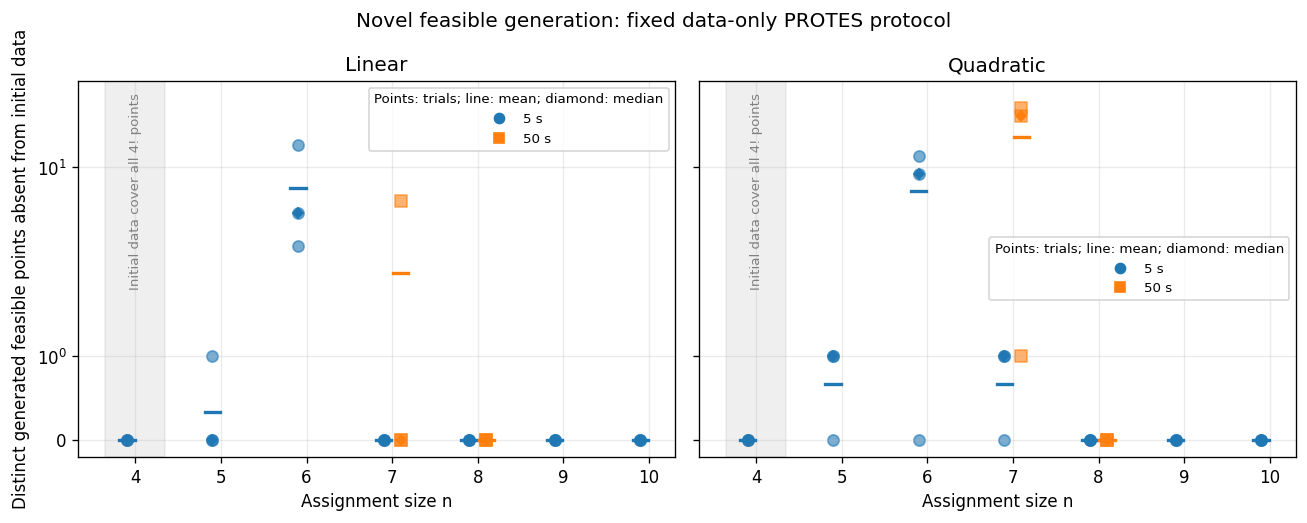

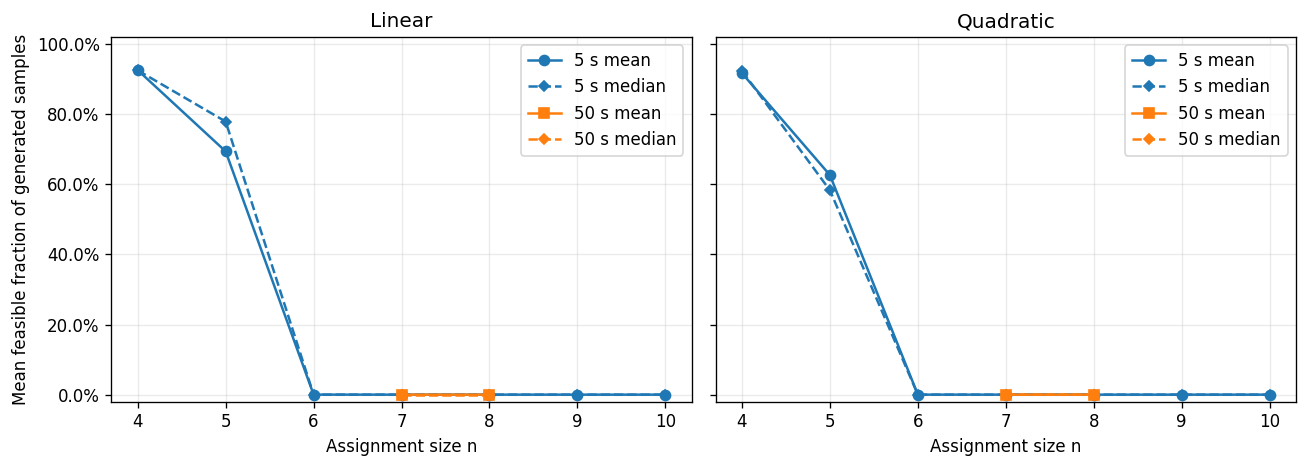

In [7]:
fig, axes = plt.subplots(1,2,figsize=(11,4.4),sharex=True,sharey=True)
common_ymax = max(2, 1.5*max(r["novel_unique"] for r in results))
for ax,obj in zip(axes,["linear","quadratic"]):
    for phase,marker,color in [("pilot","o","tab:blue"),("long","s","tab:orange")]:
        sizes=sorted({r["config"]["n"] for r in results if r["config"]["phase"]==phase and r["config"]["objective"]==obj})
        for n in sizes:
            group=[r for r in results if r["config"]["phase"]==phase and r["config"]["objective"]==obj and r["config"]["n"]==n]
            values=[r["novel_unique"] for r in group]
            x=n+(-.10 if phase=="pilot" else .10)
            ax.scatter([x]*len(values),values,marker=marker,color=color,alpha=.6,s=45)
            ax.plot([x-.09,x+.09],[np.mean(values)]*2,color=color,lw=2)
            ax.plot(x,np.median(values),marker="D",color=color,ms=4)
        ax.plot([],[],marker=marker,color=color,ls="",label="5 s" if phase=="pilot" else "50 s")
    ax.axvspan(3.65,4.35,color="gray",alpha=.12)
    ax.text(4,.97,"Initial data cover all 4! points",rotation=90,ha="center",va="top",transform=ax.get_xaxis_transform(),fontsize=8,color="gray")
    ax.set(title=obj.capitalize(),xlabel="Assignment size n",yscale="symlog",ylim=(-.2,common_ymax),xticks=range(4,11))
    ax.grid(alpha=.25);ax.legend(title="Points: trials; line: mean; diamond: median",fontsize=8,title_fontsize=8)
axes[0].set_ylabel("Distinct generated feasible points absent from initial data")
fig.suptitle("Novel feasible generation: fixed data-only PROTES protocol")
fig.tight_layout();savefig(fig,"protes_assignment_novelty_boundary");plt.show()

fig, axes=plt.subplots(1,2,figsize=(11,4),sharey=True)
for ax,obj in zip(axes,["linear","quadratic"]):
    for phase,marker in [("pilot","o"),("long","s")]:
        group=[r for r in results if r["config"]["objective"]==obj and r["config"]["phase"]==phase]
        xs=sorted({r["config"]["n"] for r in group})
        ys=[np.mean([r["feasible"]/max(1,r["generated"]) for r in group if r["config"]["n"]==n]) for n in xs]
        medians=[np.median([r["feasible"]/max(1,r["generated"]) for r in group if r["config"]["n"]==n]) for n in xs]
        color="tab:blue" if phase=="pilot" else "tab:orange"
        label="5 s" if phase=="pilot" else "50 s"
        ax.plot(xs,ys,marker=marker,color=color,label=label+" mean")
        ax.plot(xs,medians,marker="D",ls="--",color=color,label=label+" median",ms=4)
    ax.set(title=obj.capitalize(),xlabel="Assignment size n",ylim=(-.02,1.02),xticks=range(4,11))
    ax.yaxis.set_major_formatter(PercentFormatter(1,decimals=1));ax.grid(alpha=.25);ax.legend()
axes[0].set_ylabel("Mean feasible fraction of generated samples")
fig.tight_layout();savefig(fig,"protes_assignment_feasible_fraction");plt.show()

## 5. Interpreting the boundary

Zero new points when the initial dataset already covers all $n!$ solutions is not a method failure. If unseen feasible points remain, zero means only that no success was observed **in the completed runs and at this budget**. It does not prove mathematical impossibility, and the result need not be monotone in problem size.

Three failed runs give a one-sided exact binomial upper bound on success probability of $1-0.05^{1/3}$, or **63.2%** at **95.0%** confidence, assuming independent identically distributed runs. This is a weak statistical guarantee; the reported boundary is therefore empirical, not a universal critical size. A generator may repeatedly produce known feasible points without finding new ones, which differs from losing feasibility entirely.

The authors' constrained-PROTES experiments use a specially constructed initial TT indicator (`PROTES/calc/constr.py`, `calc/calc.py`), whereas structural information is deliberately withheld here. These results do not refute the authors' findings in a different setting. Four initial updates also do not guarantee a well-trained distribution.

The rank of the **full uniform indicator** is not a lower bound on the rank of a distribution sufficient for optimization. A delta distribution on one feasible solution has TT rank 1; the challenge is finding a good solution and learning a useful distribution. Exponential indicator rank and observed generation failure are therefore distinct statements, with no causal link established here.


In [8]:
for obj in ["linear","quadratic"]:
    group=[r for r in results if r["config"]["phase"]=="long" and r["config"]["objective"]==obj]
    if not group: continue
    successful=sorted({r["config"]["n"] for r in group if r["novel_unique"]>0})
    failed=[]
    for n in sorted({r["config"]["n"] for r in group}):
        at_n=[r for r in group if r["config"]["n"]==n]
        if all(r["unseen_feasible"]>0 and r["novel_unique"]==0 for r in at_n): failed.append(n)
    print(f"{obj}, 50 s: sizes with any novel success = {successful}; sizes with no novel success in all trials = {failed}.")
print("Zero successes / 3 trials: one-sided 95.0% upper bound = {:.1f}%".format(100*(1-.05**(1/3))))
print("Exact-rank growth and data-only PROTES failure are different facts; neither alone proves the other.")

linear, 50 s: sizes with any novel success = [7]; sizes with no novel success in all trials = [8].
quadratic, 50 s: sizes with any novel success = [7]; sizes with no novel success in all trials = [8].
Zero successes / 3 trials: one-sided 95.0% upper bound = 63.2%
Exact-rank growth and data-only PROTES failure are different facts; neither alone proves the other.


## 6. Sensitivity to PROTES parameters

The preceding boundary applies to the original configuration, not to PROTES under all settings. Four alternatives are declared in advance. **Configurations are not selected by their best result; all are included in the final table.** This is a diagnostic study, not a new independent SOTA test.

* `rank20`: increase model capacity while retaining the other original parameters.
* `slow10`: use a smaller learning rate and more Adam steps per batch.
* `batch400`: use one combined initial-data batch, a higher rank, and more intensive training; top-40 retains the 10.0% selection fraction.
* `fit20`: make 20 passes over the initial dataset instead of one, leaving the other parameters unchanged. The order within passes is shuffled deterministically. This tests whether failure is caused by insufficient initial training.

**Scan:** $n=4,\ldots,10$, the same seed index 0 as in the previous scan, 5 seconds, both objectives. **Main check:** $n=8$, the same three seeds and instances as before, 50 seconds, both objectives, every configuration. The short scan has fewer runs than the earlier scan; its original-configuration comparison uses the same seed index 0. Parameters and time budgets are fixed before observing outcomes. Initial training is fully included in the budget, and its completion status is recorded separately.

All tests are local. Machine and runtime details appear below. Each optimizer is pinned to one logical CPU, with one BLAS thread and JAX CPU/x64. The 1.60 GHz frequency is the processor model designation, not a measured fixed frequency: turbo behavior and the OS affect the number of samples generated within a budget.

Every configuration uses the original PROTES elite update: only the best 10.0% of each input batch is used for training. This is not simultaneous maximum-likelihood fitting to all 400 points. During generation, fully infeasible batches skip training; if fewer than `k_top` points are feasible, the selected batch also includes penalized infeasible points. These rules are held constant across configurations. Conclusions therefore apply to this adaptation of PROTES to data-only access plus a feasibility evaluator.


In [9]:
import importlib
from assignment_sensitivity import CONFIGURATIONS
config_rows=[["default",5,100,10,1,.05,1,4]]
for name,cfg in CONFIGURATIONS.items():
    config_rows.append([name,cfg["r"],cfg["k"],cfg["k_top"],cfg["k_gd"],cfg["lr"],cfg["initial_epochs"],400//cfg["k"]*cfg["initial_epochs"]*cfg["k_gd"]])
table(["Configuration","Rank","Batch","Selected","Adam steps/batch","Learning rate","Initial passes","Initial Adam steps"],config_rows)
snapshot_path=ROOT/"examples/protes_sensitivity_results.json"
snapshot=json.loads(snapshot_path.read_text()) if snapshot_path.exists() else {}
hardware=json.loads((OUT/"hardware.json").read_text()) if (OUT/"hardware.json").exists() else snapshot["hardware"]
table(["Property","Value"],[[k,v] for k,v in hardware.items()])


Configuration,Rank,Batch,Selected,Adam steps/batch,Learning rate,Initial passes,Initial Adam steps
default,5,100,10,1,0.05,1,4
rank20,20,100,10,1,0.05,1,4
slow10,5,100,10,10,0.01,1,40
batch400,10,400,40,10,0.01,1,10
fit20,5,100,10,1,0.05,20,80


Property,Value
cpu,Intel Core i5-10210U @ 1.60 GHz
physical_cores,4
logical_processors,8
ram_bytes,8415133696
platform,Windows-11-10.0.26200-SP0
host,DESKTOP-23L2I9P
experiment_cpu,0
experiment_threads,1


In [10]:
RUN_SENSITIVITY=False
if RUN_SENSITIVITY:
    for stage in ["short","long"]:
        subprocess.run([sys.executable,str(ROOT/"scripts/protes/assignment_sensitivity.py"),"--stage",stage],cwd=ROOT,check=True)
sensitivity=[json.loads(p.read_text()) for p in sorted(OUT.glob("sensitivity_*.json"))]
if not sensitivity: sensitivity=snapshot["results"]
control=[r for r in results if (r["config"]["phase"]=="pilot" and r["config"]["repetition"]==0) or
         (r["config"]["phase"]=="long" and r["config"]["n"]==8)]
def config_name(r):
    return r["config"]["phase"].split("_")[1] if r["config"]["phase"].startswith("sensitivity_") else "default"
def stage_name(r): return "short" if r["config"]["seconds"]==5 else "long"
paired=control+sensitivity
base={(r["config"]["n"],r["config"]["objective"],r["config"]["repetition"]):r for r in results}
for r in sensitivity:
    ref=base[r["config"]["n"],r["config"]["objective"],r["config"]["repetition"]]
    assert r["initial_sha256"]==ref["initial_sha256"] and r["objective_sha256"]==ref["objective_sha256"]
    assert r["novel_unique"]<=r["unseen_feasible"] and r["novel_unique"]<=r["feasible"]<=r["generated"]
print("Input hashes agree with the original study for all",len(sensitivity),"additional runs")
names=["default",*CONFIGURATIONS]
table(["Configuration","Objective","New unique: 3 trials","Feasible: 3 trials","Generated: 3 trials","Initial fit complete","Wall time, s"],
      [[name,obj,str([r["novel_unique"] for r in g]),str([r["feasible"] for r in g]),str([r["generated"] for r in g]),
        str([r["initial_training_complete"] for r in g]),f'{min(r["elapsed_seconds"] for r in g):.2f}–{max(r["elapsed_seconds"] for r in g):.2f}']
       for name in names for obj in ["linear","quadratic"]
       if (g:=sorted([r for r in paired if config_name(r)==name and stage_name(r)=="long" and r["config"]["objective"]==obj],key=lambda r:r["config"]["repetition"]))])
table(["Configuration","Objective","Feasible draws per million","Improved initial best: trials"],
      [[name,obj,f'{1e6*sum(r["feasible"] for r in g)/sum(r["generated"] for r in g):.1f}',
        f'{sum(r["c_min"]<r["initial_c_min"] for r in g)}/{len(g)}']
       for name in names for obj in ["linear","quadratic"]
       if (g:=[r for r in paired if config_name(r)==name and stage_name(r)=="long" and r["config"]["objective"]==obj])])


Input hashes agree with the original study for all 80 additional runs


Configuration,Objective,New unique: 3 trials,Feasible: 3 trials,Generated: 3 trials,Initial fit complete,"Wall time, s"
default,linear,"[0, 0, 0]","[0, 0, 0]","[3339900, 3375900, 3347700]","[True, True, True]",50.01–50.01
default,quadratic,"[0, 0, 0]","[0, 0, 0]","[3281000, 3109900, 3380600]","[True, True, True]",50.01–50.01
rank20,linear,"[0, 0, 0]","[0, 0, 0]","[1206100, 1436500, 1536300]","[True, True, True]",50.01–50.02
rank20,quadratic,"[0, 0, 0]","[0, 0, 0]","[1440800, 1553100, 1421200]","[True, True, True]",50.01–50.01
slow10,linear,"[13, 9, 4]","[13, 9, 4]","[3032400, 3132100, 2999700]","[True, True, True]",50.01–50.02
slow10,quadratic,"[6, 3, 6]","[6, 3, 6]","[2656700, 2706000, 2875300]","[True, True, True]",50.02–50.08
batch400,linear,"[0, 0, 0]","[0, 0, 0]","[3444000, 3417600, 3624800]","[True, True, True]",50.01–50.01
batch400,quadratic,"[0, 0, 0]","[0, 0, 0]","[3533600, 3480800, 3532400]","[True, True, True]",50.01–50.01
fit20,linear,"[22, 12, 25]","[23, 13, 29]","[3273700, 2887400, 3268200]","[True, True, True]",50.01–50.02
fit20,quadratic,"[17, 18, 25]","[17, 18, 26]","[3277200, 3392600, 3311900]","[True, True, True]",50.01–50.01


Configuration,Objective,Feasible draws per million,Improved initial best: trials
default,linear,0.0,0/3
default,quadratic,0.0,0/3
rank20,linear,0.0,0/3
rank20,quadratic,0.0,0/3
slow10,linear,2.8,0/3
slow10,quadratic,1.8,0/3
batch400,linear,0.0,0/3
batch400,quadratic,0.0,0/3
fit20,linear,6.9,1/3
fit20,quadratic,6.1,0/3


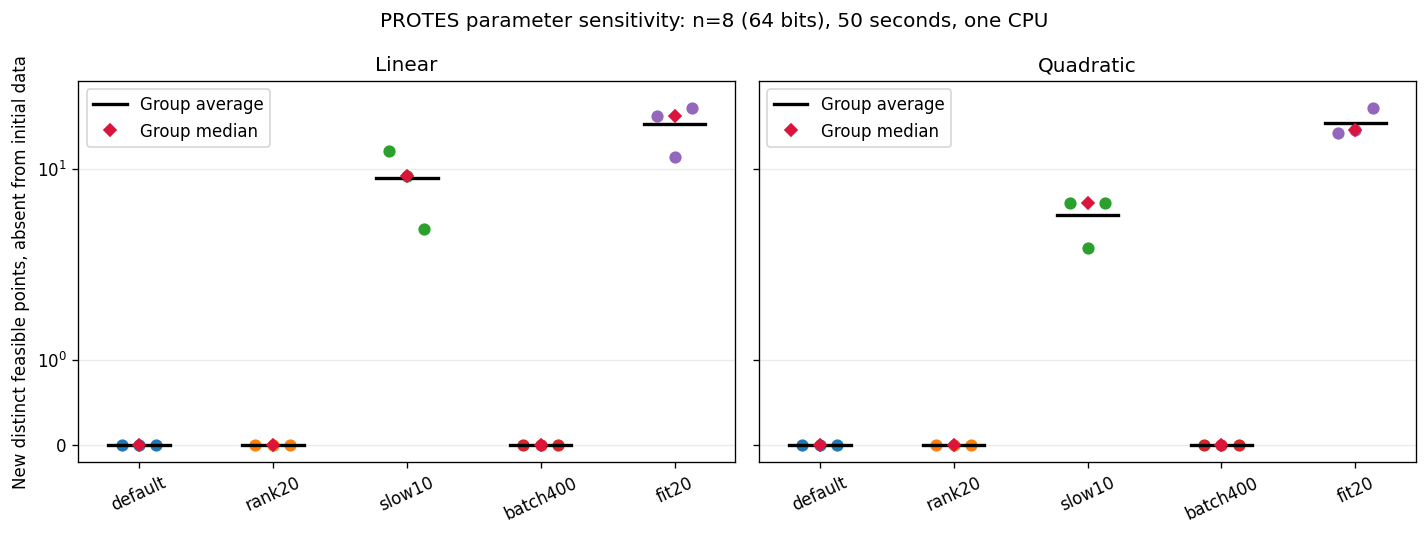

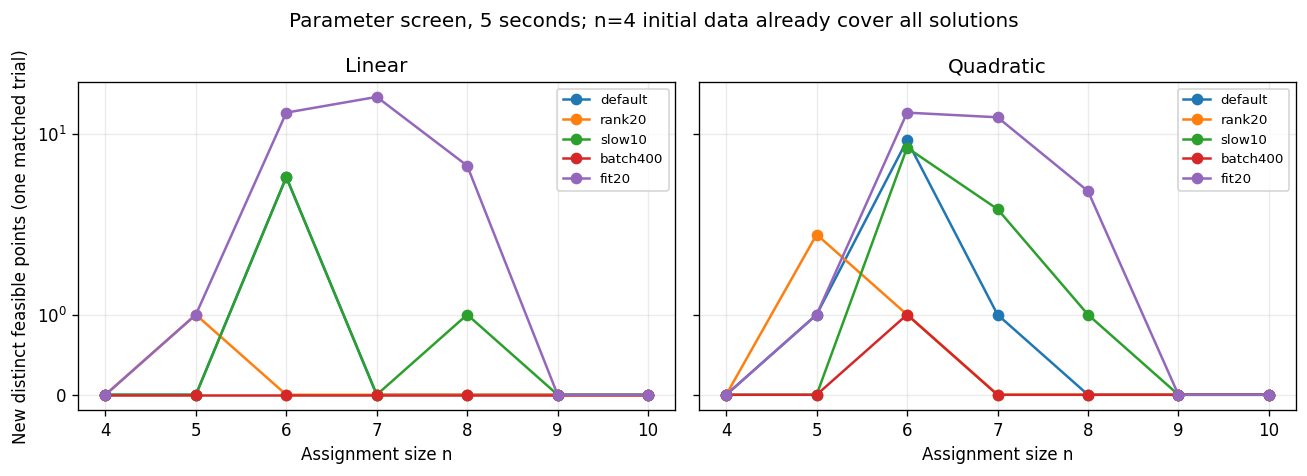

In [11]:
fig,axes=plt.subplots(1,2,figsize=(12,4.5),sharex=True,sharey=True)
colors=plt.get_cmap("tab10").colors
long_runs=[r for r in paired if stage_name(r)=="long"]
ymax=max(2,1.5*max(r["novel_unique"] for r in long_runs))
for ax,obj in zip(axes,["linear","quadratic"]):
    for j,name in enumerate(names):
        g=[r for r in long_runs if config_name(r)==name and r["config"]["objective"]==obj]
        if not g: continue
        vals=[r["novel_unique"] for r in g]
        ax.scatter(j+np.linspace(-.13,.13,len(vals)),vals,color=colors[j],s=40)
        ax.plot([j-.23,j+.23],[np.mean(vals)]*2,color="black",lw=2,label="Group average" if j==0 else None)
        ax.plot(j,np.median(vals),"D",color="crimson",ms=5,label="Group median" if j==0 else None)
    ax.set(title=obj.capitalize(),xticks=range(len(names)),xticklabels=names,yscale="symlog",ylim=(-.2,ymax))
    ax.tick_params(axis="x",labelrotation=25);ax.grid(axis="y",alpha=.25);ax.legend()
axes[0].set_ylabel("New distinct feasible points, absent from initial data")
fig.suptitle("PROTES parameter sensitivity: n=8 (64 bits), 50 seconds, one CPU")
fig.tight_layout();savefig(fig,"protes_parameter_sensitivity_50s");plt.show()

fig,axes=plt.subplots(1,2,figsize=(11,4),sharex=True,sharey=True)
short_runs=[r for r in paired if stage_name(r)=="short"]
for ax,obj in zip(axes,["linear","quadratic"]):
    for j,name in enumerate(names):
        g=sorted([r for r in short_runs if config_name(r)==name and r["config"]["objective"]==obj],key=lambda r:r["config"]["n"])
        ax.plot([r["config"]["n"] for r in g],[r["novel_unique"] for r in g],"o-",color=colors[j],label=name)
    ax.set(title=obj.capitalize(),xlabel="Assignment size n",yscale="symlog",xticks=range(4,11))
    ax.grid(alpha=.25);ax.legend(fontsize=8)
axes[0].set_ylabel("New distinct feasible points (one matched trial)")
fig.suptitle("Parameter screen, 5 seconds; n=4 initial data already cover all solutions")
fig.tight_layout();savefig(fig,"protes_parameter_sensitivity_5s");plt.show()


## 7. Dense and sparse TT cores: code inspection and memory

**The inspected version has no native sparse execution path.** In `protes/protes.py`, internal cores are combined into a dense four-dimensional JAX array and processed using `jnp.sum`, `einsum`, `lax.scan`, and Adam. In `protes_general.py`, cores are stored as a list, allowing different bond ranks, but operations still target ordinary dense arrays. In the authors' constrained example (`calc/constr.py`, `calc/calc.py`), zero entries remain in dense NumPy/JAX arrays.

Both public entry points were checked: dense cores support sampling and training, while replacing them with JAX `BCOO` raises `TypeError` at `jnp.sum`. This does not imply that sparse PROTES cannot be developed; such a version would require adapted contractions, sampling, differentiation, and optimization. Simply passing a sparse object to the existing code does not work.

This concerns the density of **TT cores**, not materializing the complete structural tensor with $2^{n^2}$ entries.

The figure compares the same **full** indicator:

* fast `protes`: $8[2(N-2)R_{max}^2+4R_{max}]$ bytes of float64 parameters;
* `protes_general`: $16\sum_{k=1}^N R_{k-1}R_k$ bytes at the exact minimum rank profile;
* U(1): the exact number of allowed scalar blocks, at 8 bytes per block;
* actual U(1) object size from `Base.summarysize(mps)` for $n\le16$, including dictionaries, charges, matrix A, and other reachable fields.

The full U(1) indicator is constructed from all reachable residual charges through the existing `init_u1_mps`, without enumerating $n!$ permutations. Overhead therefore applies to this construction. `summarysize` measures the object graph, **not peak process RSS**. PROTES estimates cover parameter arrays; Adam states and gradients increase training memory. U(1) training work buffers are also excluded.

The exact block count at position $(r,s)$, after $r$ complete rows and $s$ columns of the next row, is
$$E_{r,s}=\binom{n-1}r+\binom nr-\binom{s+1}{r-n+s+1}+\binom n{r+1}-\binom{n-s}{r+1}.$$
The first term counts $x=1$ transitions; the remaining terms count $x=0$ transitions before/after selecting the row's one. The sum over all positions is checked against the actual Julia block dictionaries.


Interface / storage,Success,Diagnostic
protes_dense,True,
protes_BCOO,False,"sum requires ndarray or scalar arguments, got <class 'jax.experimental.sparse.bcoo.BCOO'> at position 0."
protes_general_dense,True,
protes_general_BCOO,False,"sum requires ndarray or scalar arguments, got <class 'jax.experimental.sparse.bcoo.BCOO'> at position 0."
protes_general_variable_dense_ranks,True,


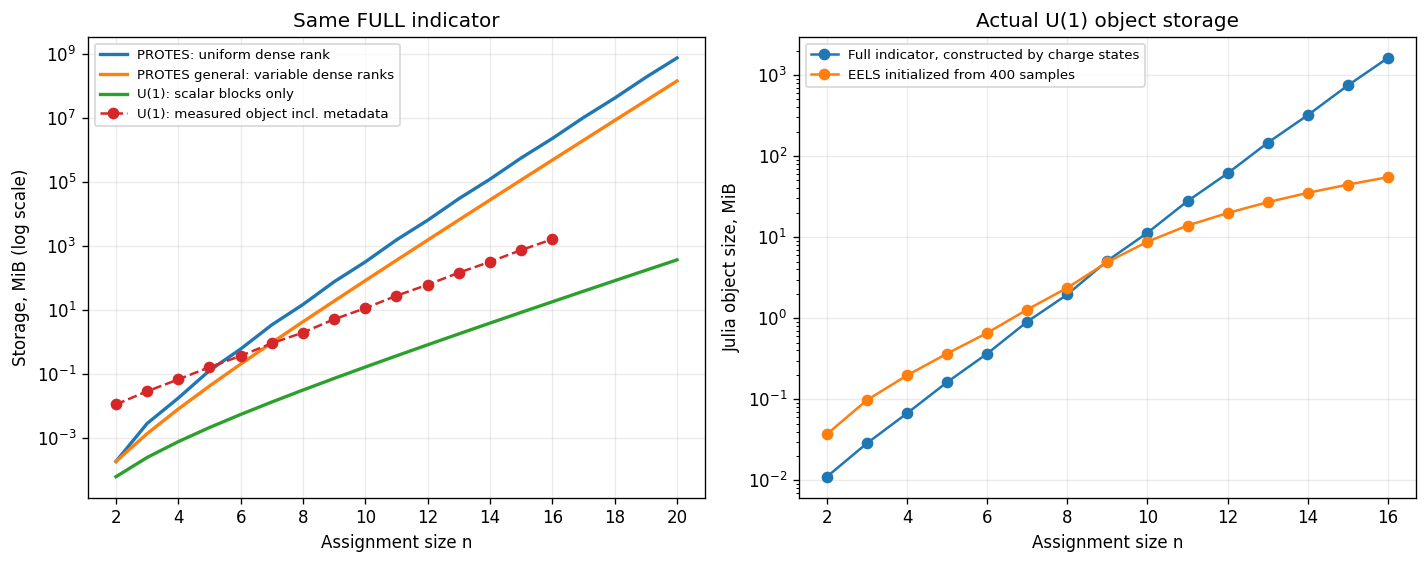

n,"Dense PROTES, GiB","Dense general, GiB","U(1) scalar blocks, MiB","Full U(1) object, MiB"
8,0.0144,0.00417,0.0313,1.96
10,0.31,0.0808,0.164,11.3
12,6.22,1.49,0.813,61.3
16,2.24e+03,472,18,1.62e+03


In [12]:
sparse_report=json.loads((OUT/"sparse_support.json").read_text()) if (OUT/"sparse_support.json").exists() else snapshot["sparse_support"]
table(["Interface / storage","Success","Diagnostic"],[[k,v["success"],v.get("message","")] for k,v in sparse_report.items()])
memory_file=OUT/"memory.csv"
if not memory_file.exists(): memory_file=ROOT/"examples/protes_scaling_memory.csv"
with memory_file.open() as f: memory=list(csv.DictReader(f))
def exact_blocks(n):
    C=analysis.choose
    return sum(C(n-1,r)+C(n,r)-C(s+1,r-n+s+1)+C(n,r+1)-C(n-s,r+1) for r in range(n) for s in range(n))
def memory_sizes(n):
    rs=[analysis.exact_rank(n,k) for k in range(n*n+1)];R=max(rs)
    return 8*(2*(n*n-2)*R*R+4*R),16*sum(a*b for a,b in zip(rs[:-1],rs[1:])),8*exact_blocks(n)
for row in memory:
    if row["mode"]=="full":
        assert int(row["blocks"])==exact_blocks(int(row["n"]))
        assert int(row["numeric_bytes"])==8*int(row["blocks"])
ns=np.arange(2,21)
sizes=np.array([memory_sizes(int(n)) for n in ns])
full=sorted([r for r in memory if r["mode"]=="full"],key=lambda r:int(r["n"]))
sample=sorted([r for r in memory if r["mode"]=="EELS"],key=lambda r:int(r["n"]))
fig,(ax,ax2)=plt.subplots(1,2,figsize=(12,4.8))
for j,label in enumerate(["PROTES: uniform dense rank","PROTES general: variable dense ranks","U(1): scalar blocks only"]):
    ax.semilogy(ns,sizes[:,j]/2**20,label=label,lw=2)
ax.semilogy([int(r["n"]) for r in full],[int(r["julia_summarysize_bytes"])/2**20 for r in full],"o--",label="U(1): measured object incl. metadata")
ax.set(xlabel="Assignment size n",ylabel="Storage, MiB (log scale)",title="Same FULL indicator",xticks=range(2,21,2));ax.legend(fontsize=8);ax.grid(alpha=.25)
for mode,label in [("full","Full indicator, constructed by charge states"),("EELS","EELS initialized from 400 samples")]:
    rows=sorted([r for r in memory if r["mode"]==mode],key=lambda r:int(r["n"]))
    ax2.semilogy([int(r["n"]) for r in rows],[int(r["julia_summarysize_bytes"])/2**20 for r in rows],"o-",label=label)
ax2.set(xlabel="Assignment size n",ylabel="Julia object size, MiB",title="Actual U(1) object storage",xticks=range(2,17,2));ax2.legend(fontsize=8);ax2.grid(alpha=.25)
fig.tight_layout();savefig(fig,"assignment_mps_memory_comparison");plt.show()
table(["n","Dense PROTES, GiB","Dense general, GiB","U(1) scalar blocks, MiB","Full U(1) object, MiB"],
      [[n,f"{memory_sizes(n)[0]/2**30:.3g}",f"{memory_sizes(n)[1]/2**30:.3g}",f"{memory_sizes(n)[2]/2**20:.3g}",
        next((f'{int(r["julia_summarysize_bytes"])/2**20:.3g}' for r in full if int(r["n"])==n),"not measured")]
       for n in [8,10,12,16]])


## 8. Updated conclusion

The original failure at $n=8$ cannot automatically be generalized to other parameters. Here, success means generating at least one **new** feasible point; total feasible samples and final costs are saved separately. A high feasible fraction can reflect repeated known solutions rather than effective search.

If any alternative configuration succeeds, this experiment refutes the categorical claim that "PROTES cannot generate feasible points from samples at this size." The results may support statements about observed rarity or instability, sensitivity to initialization, and computational cost. A small number of seeds cannot establish impossibility, even if every run returns zero new points.


In [13]:
for obj in ["linear","quadratic"]:
    for name in names:
        g=[r for r in long_runs if config_name(r)==name and r["config"]["objective"]==obj]
        if g: print(f"{obj:9s} {name:9s}: success {sum(r['novel_unique']>0 for r in g)}/{len(g)}, new points {[r['novel_unique'] for r in g]}")
if any(r["novel_unique"]>0 for r in sensitivity if stage_name(r)=="long"):
    print("Conclusion: the original n=8 zero-generation observation is NOT robust to these parameter changes.")
else:
    print("No new feasible points observed at n=8 in these configurations and budgets; this is not an impossibility proof.")


linear    default  : success 0/3, new points [0, 0, 0]
linear    rank20   : success 0/3, new points [0, 0, 0]
linear    slow10   : success 3/3, new points [13, 9, 4]
linear    batch400 : success 0/3, new points [0, 0, 0]
linear    fit20    : success 3/3, new points [22, 12, 25]
quadratic default  : success 0/3, new points [0, 0, 0]
quadratic rank20   : success 0/3, new points [0, 0, 0]
quadratic slow10   : success 3/3, new points [6, 3, 6]
quadratic batch400 : success 0/3, new points [0, 0, 0]
quadratic fit20    : success 3/3, new points [17, 18, 25]
Conclusion: the original n=8 zero-generation observation is NOT robust to these parameter changes.


## 9. Constructed full models and sampling speed

**Clarification of the earlier experiment:** the previous large PROTES memory figures were analytical estimates of dense cores, not actual allocations. U(1) objects had been constructed up to $n=12$. Full U(1)-MPS have now been built up to $n=16$, and both dense PROTES implementations for $n=4,\ldots,10$. Larger PROTES models were not allocated on this laptop: at $n=16$, even variable-rank storage requires hundreds of GiB. Missing points are not replaced with invented speed measurements.

Both models represent **all** permutations in the same row-major binary order. Dynamic programming retains the set of occupied columns at each cut. Allowed transitions receive ones and other transitions zeros. Exact ranks and the path count $n!$ are verified.

For U(1), a backward pass counts completions $C_k(q)$. Each scalar block is replaced by $\sqrt{C_{k+1}(q')/C_k(q)}$. The product along any path is $1/\sqrt{n!}$, giving the exact right-canonical form of the uniform distribution. The project's unmodified `sample_nondeg!` is used. Preparing this form is excluded from sampling time and recorded separately.

PROTES indicator cores are actually allocated as dense arrays: padded to a common rank for fast `protes`, and using minimum variable ranks for `protes_general`. Their unmodified `_sample`, `_interface_matrices`, and JAX vectorization are used. This is the uniform distribution on the same $n!$ points. Training is disabled: the benchmark measures sampling from an exactly specified model.

**Timing protocol:** the same logical CPU 0; float64; batches of 100; three seeds; at least one second of cumulative generator-call time per seed. Construction, JIT warm-up, feasibility checks, and unique-point counting are excluded for both methods. PROTES timing includes transferring results to the CPU and recomputing right environments for each batch, as in its standard loop. Actual batch counts and durations are saved; a large batch can exceed one second. The primary metric is therefore samples/second, and unique-point counts are accompanied by actual durations.

"New" points are absent from the same reference dataset of 400 points (`linear`, seed index 0), which is not used to construct the full indicator. At $n=4$, that dataset already covers the entire space, so no new points can exist. At $n=5$, few unseen solutions remain. **Total sampling throughput and new-unique-point throughput are different metrics.**

Object sizes are measured in a separate full `Base.summarysize` traversal. Initial runs at $n=15,16$ showed memory pressure and paging on the 8 GB RAM machine. Speed runs were therefore repeated without the deep memory traversal, with `GC.gc()` before warm-up; initial results are preserved in the snapshot as `full_u1_initial_memory_audit`. The figure shows repeat measurements and their range. These are local measurements of this implementation and machine, not hardware-independent complexity estimates.


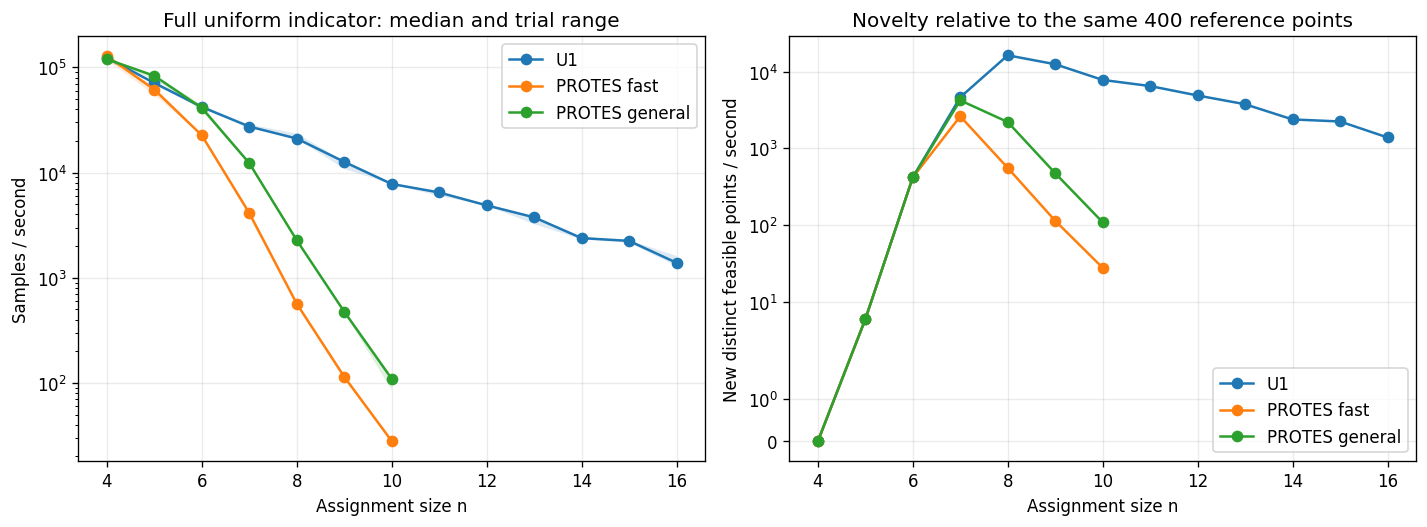

n,Sampler,Median samples/s,Feasible / generated,Unique per trial,New per trial,Measured seconds per trial
4,U1,123633.0,372200 / 372200,"[24, 24, 24]","[0, 0, 0]","[1.0, 1.001, 1.001]"
4,PROTES fast,128528.0,376700 / 376700,"[24, 24, 24]","[0, 0, 0]","[1.0, 1.001, 1.001]"
4,PROTES general,119899.1,352800 / 352800,"[24, 24, 24]","[0, 0, 0]","[1.001, 1.001, 1.0]"
5,U1,71180.3,211600 / 211600,"[120, 120, 120]","[6, 6, 6]","[1.001, 1.0, 1.0]"
5,PROTES fast,61537.5,182600 / 182600,"[120, 120, 120]","[6, 6, 6]","[1.001, 1.001, 1.0]"
5,PROTES general,83220.7,245900 / 245900,"[120, 120, 120]","[6, 6, 6]","[1.0, 1.001, 1.0]"
6,U1,42087.1,126900 / 126900,"[720, 720, 720]","[420, 420, 420]","[1.0, 1.001, 1.003]"
6,PROTES fast,22632.2,68200 / 68200,"[720, 720, 720]","[420, 420, 420]","[1.002, 1.002, 1.003]"
6,PROTES general,41250.7,124400 / 124400,"[720, 720, 720]","[420, 420, 420]","[1.001, 1.0, 1.001]"
7,U1,27388.9,83300 / 83300,"[5024, 5011, 5019]","[4638, 4628, 4634]","[1.001, 1.002, 1.0]"


n,U1 / PROTES fast throughput,U1 / PROTES general throughput
4,0.96,1.03
5,1.16,0.86
6,1.86,1.02
7,6.64,2.23
8,37.19,9.26
9,110.50,26.59
10,278.25,71.12


In [14]:
full_snapshot=json.loads((ROOT/'examples/protes_full_comparison_results.json').read_text())
u1_full=full_snapshot['full_u1']
dense_full=full_snapshot['full_protes']
full_trials=[dict(r,method='U1') for r in u1_full]
for result in dense_full:
    full_trials.extend(dict(r,method='PROTES '+result['variant']) for r in result['trials'])
methods=['U1','PROTES fast','PROTES general']
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
for j,method in enumerate(methods):
    sizes=sorted({int(r['n']) for r in full_trials if r['method']==method})
    med=[];lo=[];hi=[];new=[]
    for n in sizes:
        g=[r for r in full_trials if r['method']==method and int(r['n'])==n]
        rates=[float(r['samples_per_second']) for r in g]
        med.append(np.median(rates));lo.append(min(rates));hi.append(max(rates))
        new.append(np.median([int(r['novel_unique'])/float(r['seconds']) for r in g]))
    axes[0].semilogy(sizes,med,'o-',label=method)
    axes[0].fill_between(sizes,lo,hi,alpha=.15)
    axes[1].plot(sizes,new,'o-',label=method)
axes[0].set(ylabel='Samples / second',title='Full uniform indicator: median and trial range')
axes[1].set(ylabel='New distinct feasible points / second',yscale='symlog',title='Novelty relative to the same 400 reference points')
for ax in axes:
    ax.set(xlabel='Assignment size n',xticks=range(4,17,2));ax.grid(alpha=.25);ax.legend()
fig.tight_layout();savefig(fig,'assignment_full_sampling_speed');plt.show()
table(['n','Sampler','Median samples/s','Feasible / generated','Unique per trial','New per trial','Measured seconds per trial'],
      [[n,method,f'{np.median([float(r["samples_per_second"]) for r in g]):.1f}',
        f'{sum(int(r["feasible"]) for r in g)} / {sum(int(r["samples"]) for r in g)}',
        str([int(r['unique']) for r in g]),str([int(r['novel_unique']) for r in g]),
        str([round(float(r['seconds']),3) for r in g])]
       for n in range(4,17) for method in methods
       if (g:=[r for r in full_trials if int(r['n'])==n and r['method']==method])])
table(['n','U1 / PROTES fast throughput','U1 / PROTES general throughput'],
      [[n,*[f'{np.median([float(r["samples_per_second"]) for r in full_trials if int(r["n"])==n and r["method"]=="U1"])/np.median([float(r["samples_per_second"]) for r in full_trials if int(r["n"])==n and r["method"]==method]):.2f}'
             for method in ['PROTES fast','PROTES general']]] for n in range(4,11)])


## 10. U(1)-EELS and PROTES with identical initial data and time budgets

U(1)-EELS is now constructed **only from the same 400 observations**, not the full feasible set. Observations and objective functions are exported from NumPy without regeneration by the Julia RNG; SHA-256 fingerprints of the original bytes are verified in both languages. A fundamental difference in structural access remains: U(1) uses $A,b$, while PROTES receives only data and an external evaluator. Thus this compares the specified settings, rather than isolating architecture effects under identical information.

EELS parameters: $\gamma=1$, sector degeneracy 1, one bidirectional training sweep, learning rate 0.05, up to 400 best points retained for the next iteration, and 10000 draws per iteration. No external feasible points are added after initialization. Training uses the same Boltzmann weights and updates as `run_EELS_optimization.jl`. To compare **time**, the number of outer iterations is limited by a deadline rather than the previous fixed value of 20; actual iteration counts are recorded. Sampling is divided into batches of 100 for deadline checks. A batch completed after the deadline is rejected, as in PROTES. Construction, training, objective evaluation, and novelty accounting are included in the budget. The deadline is cooperative: an ongoing construction/training operation can exceed it; actual durations are reported below.

One complete iteration at the same size is used for warm-up before measurement; neither the warm-up model nor its data is carried into the measured run. All runs are sequential, on one logical CPU, without competing benchmarks running concurrently. The scan uses $n=4,\ldots,10$, one seed, and 5 seconds. Long runs use $n=8$, three seeds, 50 seconds, and both objectives. These are the same diagnostic instances, not new held-out test files from the article.


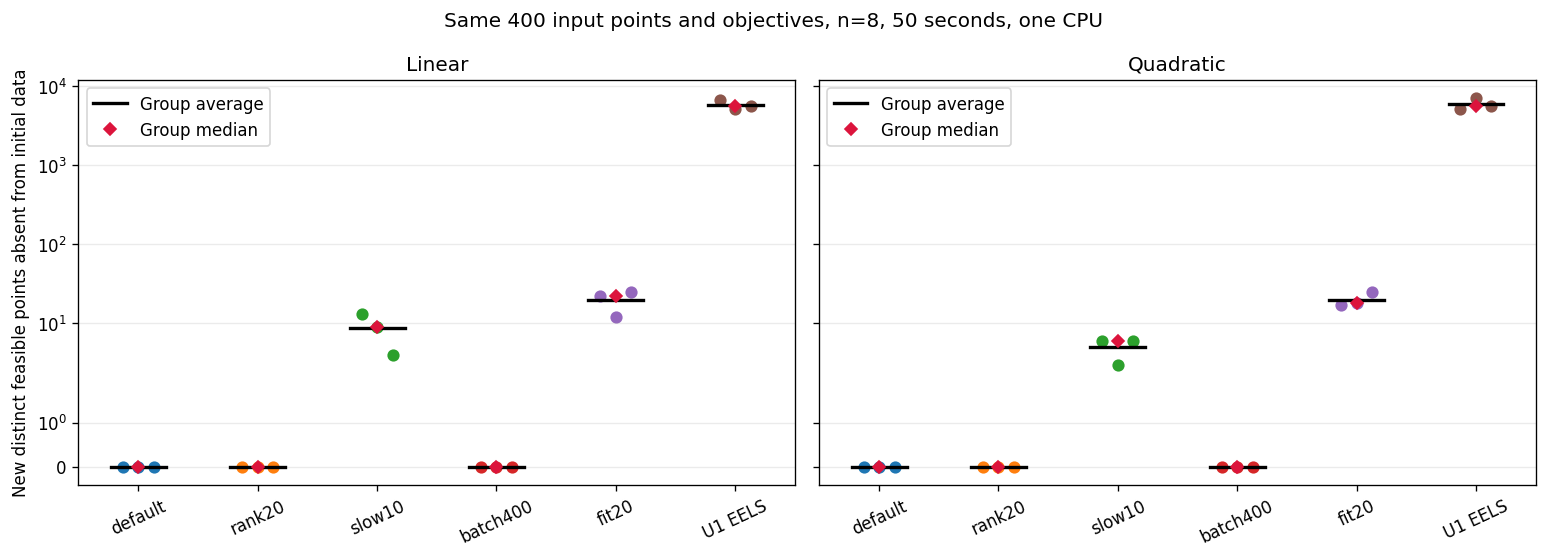

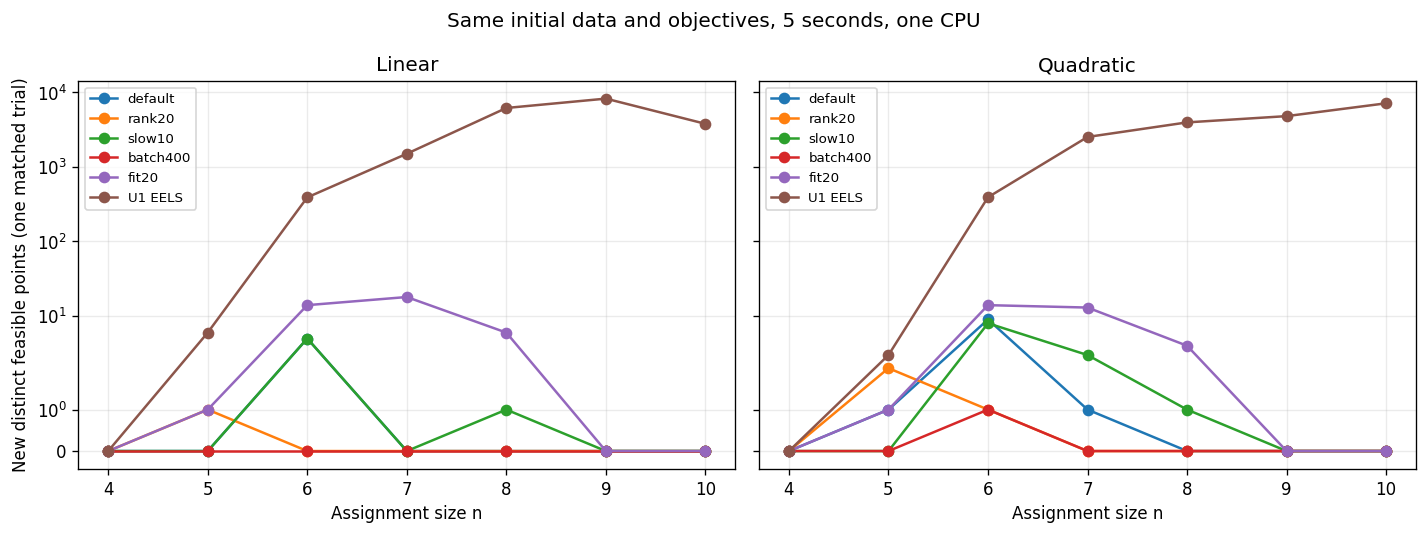

n,Objective,Seed index,Budget,Actual seconds,Generated,New unique,Iterations started/completed,Initial fit complete,Initial best,Final best
4,linear,0,5.0,5.000,362000,0,37/36,true,-5.469,-5.469
4,quadratic,0,5.0,5.000,444400,0,45/44,true,-36.981,-36.981
5,linear,0,5.0,5.000,248000,6,25/24,true,-111.128,-111.128
5,quadratic,0,5.0,5.001,182800,3,19/18,true,-40.806,-40.806
6,linear,0,5.0,5.000,140300,390,15/14,true,-133.459,-133.459
6,quadratic,0,5.0,5.000,144700,392,15/14,true,-58.852,-91.105
7,linear,0,5.0,5.001,91900,1501,10/9,true,-150.140,-172.612
7,quadratic,0,5.0,5.001,95100,2520,10/9,true,-85.053,-94.657
8,linear,0,5.0,5.000,66100,6165,7/6,true,-283.707,-283.707
8,quadratic,0,5.0,5.004,65500,3951,7/6,true,-90.064,-125.638


In [15]:
u1_data=full_snapshot['data_u1']
for r in u1_data:
    ref=base[int(r['n']),r['objective'],int(r['repetition'])]
    assert r['initial_sha256']==ref['initial_sha256'] and r['objective_sha256']==ref['objective_sha256']
    assert int(r['generated'])==int(r['feasible'])
    assert int(r['novel_unique'])<=ref['unseen_feasible']
u1_long=[r for r in u1_data if float(r['budget'])==50]
comparison_names=names+['U1 EELS']
fig,axes=plt.subplots(1,2,figsize=(13,4.7),sharex=True,sharey=True)
for ax,obj in zip(axes,['linear','quadratic']):
    for j,name in enumerate(comparison_names):
        g=([r for r in u1_long if r['objective']==obj] if name=='U1 EELS' else
           [r for r in long_runs if config_name(r)==name and r['config']['objective']==obj])
        vals=[int(r['novel_unique']) for r in g]
        ax.scatter(j+np.linspace(-.13,.13,len(vals)),vals,color=colors[j],s=40)
        ax.plot([j-.23,j+.23],[np.mean(vals)]*2,color='black',lw=2,label='Group average' if j==0 else None)
        ax.plot(j,np.median(vals),'D',color='crimson',ms=5,label='Group median' if j==0 else None)
    ax.set(title=obj.capitalize(),xticks=range(len(comparison_names)),xticklabels=comparison_names,yscale='symlog')
    ax.tick_params(axis='x',labelrotation=25);ax.grid(axis='y',alpha=.25);ax.legend()
axes[0].set_ylabel('New distinct feasible points absent from initial data')
fig.suptitle('Same 400 input points and objectives, n=8, 50 seconds, one CPU')
fig.tight_layout();savefig(fig,'protes_u1_parameter_comparison_50s');plt.show()
fig,axes=plt.subplots(1,2,figsize=(12,4.5),sharex=True,sharey=True)
for ax,obj in zip(axes,['linear','quadratic']):
    for j,name in enumerate(comparison_names):
        if name=='U1 EELS':
            g=sorted([r for r in u1_data if r['objective']==obj and float(r['budget'])==5],key=lambda r:int(r['n']))
            xs=[int(r['n']) for r in g]
        else:
            g=sorted([r for r in short_runs if config_name(r)==name and r['config']['objective']==obj],key=lambda r:r['config']['n'])
            xs=[r['config']['n'] for r in g]
        ax.plot(xs,[int(r['novel_unique']) for r in g],'o-',label=name,color=colors[j])
    ax.set(title=obj.capitalize(),xlabel='Assignment size n',yscale='symlog',xticks=range(4,11));ax.grid(alpha=.25);ax.legend(fontsize=8)
axes[0].set_ylabel('New distinct feasible points (one matched trial)')
fig.suptitle('Same initial data and objectives, 5 seconds, one CPU')
fig.tight_layout();savefig(fig,'protes_u1_parameter_comparison_5s');plt.show()
table(['n','Objective','Seed index','Budget','Actual seconds','Generated','New unique','Iterations started/completed','Initial fit complete','Initial best','Final best'],
      [[r['n'],r['objective'],r['repetition'],r['budget'],f'{float(r["elapsed_seconds"]):.3f}',r['generated'],r['novel_unique'],
        f'{r["iterations"]}/{r["completed_iterations"]}',r['initial_training_complete'],f'{float(r["initial_c_min"]):.3f}',f'{float(r["c_min"]):.3f}'] for r in u1_data])


## 11. Limits of interpretation

The full-model comparison measures storage efficiency and the specific native samplers under the same uniform distribution. It does not measure learned-model quality or time to reach a good objective value. Compact storage alone does not guarantee faster sampling: dictionaries, memory allocation, JIT, and vectorization affect performance.

The sample-based comparison separately measures new feasible points under a shared computational budget. U(1)-EELS uses constraints in its representation, while PROTES does not receive them in this protocol. In small spaces, novelty is limited by the remaining unseen solutions; in large spaces, novelty does not imply good cost. Best objective values and actual durations are therefore also retained.
